# Running your first mission

This walkthrough sizes a small turboprop with the current PhlyGreen API: build a wired
aircraft, describe the design with a **typed configuration**, run the sizing loop, read
the **structured results**, and plot the outcomes.

## 1. Build a wired aircraft

`build_aircraft()` creates every subsystem and cross-links them (the mediator pattern).

In [1]:
import matplotlib.pyplot as plt
import PhlyGreen as pg
from PhlyGreen import postprocess as pp
from PhlyGreen.config import (AircraftConfig, MissionConfig, EnergyConfig,
    AerodynamicsConfig, ConstraintsConfig, StagesConfig, Segment)

aircraft = pg.build_aircraft()

## 2. Describe the design

Inputs are typed, validated dataclasses. Change any field to explore the design.

In [2]:
config = AircraftConfig(
    configuration='Traditional', aircraft_type='ATR', weight_class='I',
    mission=MissionConfig(range_mission=750, range_diversion=220, beta_start=0.97,
                          payload_weight=4560, crew_weight=500),
    energy=EnergyConfig(Ef=43.5e6, contingency_fuel=130, eta_gearbox=0.96,
                        eta_gas_turbine=0.22, eta_propulsive=0.9,
                        specific_power_powertrain=[3900, 7700]),
    aerodynamics=AerodynamicsConfig(take_off_cl=1.9, landing_cl=1.9, minimum_cl=0.2,
        cd0=0.017, analytic_polar={'type': 'Quadratic', 'input': {'AR': 11, 'e_osw': 0.8}}),
    constraints=ConstraintsConfig(disa=0.0, phases={
        'Cruise':       {'Speed': 0.5, 'Speed Type': 'Mach', 'Beta': 0.95, 'Altitude': 8000.},
        'AEO Climb':    {'Speed': 210, 'Speed Type': 'KCAS', 'Beta': 0.97, 'Altitude': 6000., 'ROC': 5},
        'OEI Climb':    {'Speed': 41.4, 'Speed Type': 'TAS', 'Beta': 1., 'Altitude': 0., 'Climb Gradient': 0.021},
        'Take Off':     {'Speed': 90, 'Speed Type': 'TAS', 'Beta': 1., 'Altitude': 100., 'kTO': 1.2, 'sTO': 950},
        'Landing':      {'Speed': 59., 'Speed Type': 'TAS', 'Altitude': 500.},
        'Turn':         {'Speed': 210, 'Speed Type': 'KCAS', 'Beta': 0.9, 'Altitude': 5000, 'Load Factor': 1.1},
        'Ceiling':      {'Speed': 0.5, 'Beta': 0.8, 'Altitude': 9500, 'HT': 0.5},
        'Acceleration': {'Mach 1': 0.3, 'Mach 2': 0.4, 'DT': 180, 'Altitude': 6000, 'Beta': 0.9}}),
    mission_stages=StagesConfig(segments=[
        Segment('Takeoff', phi=0.0),
        Segment('Climb1', 'ConstantRateClimb', {'CB': 0.16, 'Speed': 77, 'StartAltitude': 100, 'EndAltitude': 1500}),
        Segment('Climb2', 'ConstantRateClimb', {'CB': 0.08, 'Speed': 120, 'StartAltitude': 1500, 'EndAltitude': 4500}),
        Segment('Climb3', 'ConstantRateClimb', {'CB': 0.07, 'Speed': 125, 'StartAltitude': 4500, 'EndAltitude': 8000}),
        Segment('Cruise', 'ConstantMachCruise', {'Mach': 0.4, 'Altitude': 8000}),
        Segment('Descent1', 'ConstantRateDescent', {'CB': -0.04, 'Speed': 90, 'StartAltitude': 8000, 'EndAltitude': 200})]),
    diversion_stages=StagesConfig(segments=[
        Segment('Climb1', 'ConstantRateClimb', {'CB': 0.08, 'Speed': 110, 'StartAltitude': 200, 'EndAltitude': 3100}),
        Segment('Cruise', 'ConstantMachCruise', {'Mach': 0.35, 'Altitude': 3100}),
        Segment('Descent1', 'ConstantRateDescent', {'CB': -0.04, 'Speed': 90, 'StartAltitude': 3100, 'EndAltitude': 200})]),
)

## 3. Size the aircraft

`configure` finds the design point on the constraint diagram, then iterates the
take-off weight to convergence.

In [3]:
aircraft.configure(config)
r = aircraft.results()
print(f'take-off weight : {r.WTO:8.1f} kg')
print(f'block fuel      : {r.block_fuel:8.1f} kg')
print(f'wing area       : {r.WingSurface:8.1f} m^2')

take-off weight :  18327.5 kg
block fuel      :   2037.6 kg
wing area       :     54.6 m^2


## 4. Plot the outcomes

The `postprocess` helpers work for any configuration.

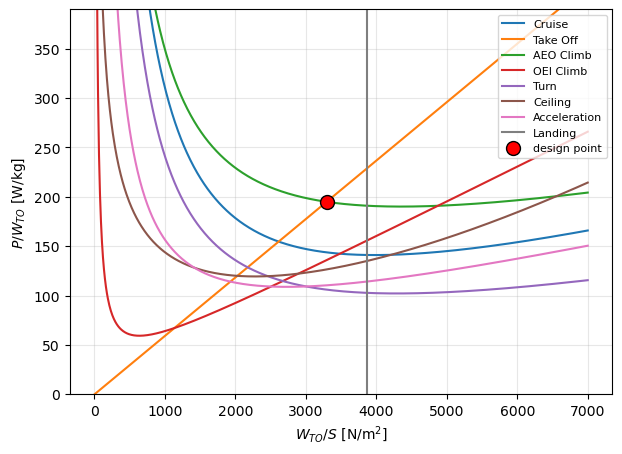

In [4]:
pp.plot_constraint_diagram(aircraft); plt.show()

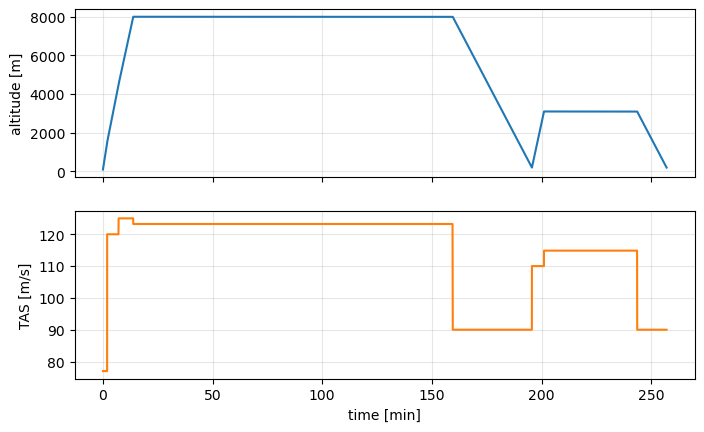

In [5]:
pp.plot_mission_profile(aircraft); plt.show()

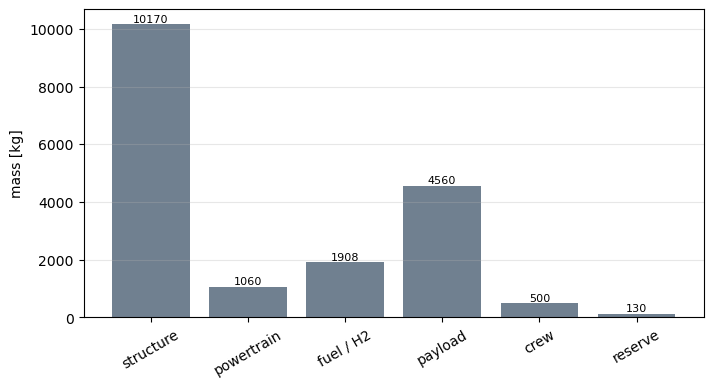

In [6]:
pp.plot_mass_breakdown(aircraft); plt.show()

## Next steps

- Change inputs above (range, payload, cruise Mach) and re-run.
- Try `hybrid`, `Hydrogen` and `FuelCellBattery` configurations — see the notebooks in
  `trunk/notebooks/` and the scripts in `trunk/examples/`.